In [43]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# Load the pFBA results 
with open('../../check_cue/results.pkl', 'rb') as f:
    fba_results = pickle.load(f)

In [45]:
# Save the fluxes as a JSON
fba_results["glc_medium_real_o2_pfba"].fluxes.to_json("glc_medium_real_o2_pfba_fluxes.json")
fba_results["ace_medium_real_o2_pfba"].fluxes.to_json("ace_medium_real_o2_pfba_fluxes.json")

In [47]:
fba_results["glc_medium_real_o2_pfba"].fluxes["rxn05226_c0"]

np.float64(10.0)

In [9]:
# Load the excel file as a pandas dataframe
proteomics_data = pd.read_excel("Proteomic data MIT1002 for Helen.xlsx")

In [15]:
# Give better names to the "Mean" columns for the glucose and acetate spectral countrs
proteomics_data.rename(columns={"Mean": "Ace12 Percent Mean",
                                "mean": "Glc12 Percent Mean",
                                "Mean.1": "Ace12 Counts Mean",
                                "Mean.2": "Glc12 Counts Mean"
                                }, inplace=True)

In [16]:
proteomics_data

,Locus Tag,enzyme,Function,gene caller,221018_ccomp_9_MIT_1002_Ace_12_a_30_mL Spectral Count,221018_ccomp_2_MIT_1002_Ace12_B Spectral Count,221018_ccomp_1_MIT_1002_Ace12_C Spectral Count,Ace12 Spectral Count Mean,220427_CCoMP_AHANA_MIT1002_CS_a1 Spectral Count,220427_CCoMP_AHANA_MIT1002_CS_b1 Spectral Count,...,220427_CCoMP_AHANA_MIT1002_CS_c1 Spectral Count.1,Glc12 Counts Mean,221018_ccomp_17_MIT1002_30ml_Gluc4_Ace8_A_T5 Spectral Count.1,221018_ccomp_4_MIT_1002_30_mL_Gluc_4_Ace_8_BTS Spectral Count.1,221018_ccomp_18_MIT1002_30ml_Gluc4_Ace8_C_T5 Spectral Count.1,221018_ccomp_6_MIT_1002_30_mL_Gluc_4_Ace_8_A_T8 Spectral Count.1,221018_ccomp_10_MIT_1002_Gluc_4_Ace_8_B_T8_30_mL Spectral Count.1,221018_ccomp_14_MIT1002_30ml_Gluc4_Ace8_c_T8 Spectral Count.1,Unnamed: 33,Unnamed: 34
0,MIT1002_02404,1.0,Glucokinase,2321.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,2.0,2.0,0.0,1.0,0.0,0.0,NaN,Data in Columns E-R are percent of total spect...
1,MIT1002_02402,2.0,Glucose-6-phosphate 1-epimerase,2319.0,0.028712,0.026765,0.034652,0.030043,0.020506,0.032570,...,7.0,8.333333,13.0,12.0,13.0,8.0,10.0,6.0,NaN,Data in Columns T-AG are spectral counts in th...
2,MIT1002_03081,3.0,Glucose-6-phosphate isomerase,2977.0,0.057425,0.062451,0.048513,0.056130,0.058589,0.059219,...,21.0,20.333333,22.0,20.0,19.0,22.0,25.0,19.0,NaN,NaN
3,MIT1002_01991,4.0,6-phosphofructokinase isozyme 1,1912.0,0.071781,0.051299,0.060064,0.061048,0.049801,0.050336,...,27.0,20.333333,57.0,56.0,65.0,30.0,24.0,28.0,NaN,Blue highlights = 12 mM acetate
4,MIT1002_00864,5.0,Fructose-bisphosphate aldolase class 1,842.0,0.004785,0.008922,0.002310,0.005339,0.005859,0.002961,...,2.0,1.666667,1.0,7.0,2.0,8.0,7.0,2.0,NaN,Green highlights = 12 mM glucose
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2954,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.005922,...,0.0,0.666667,0.0,1.0,0.0,1.0,2.0,0.0,NaN,NaN
2955,NaN,NaN,NaN,NaN,0.000000,0.004461,0.002310,0.002257,0.005859,0.014805,...,0.0,2.333333,4.0,5.0,3.0,7.0,10.0,8.0,NaN,NaN
2956,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2957,NaN,NaN,Chromosomal replication initiator protein DnaA,0.0,0.081351,0.066912,0.083166,0.077143,0.111319,0.118438,...,37.0,38.333333,29.0,28.0,33.0,33.0,29.0,39.0,NaN,NaN


In [17]:
# Define a mapping from the enzyme names in the proteomics data to the reaction IDs in the model
name_to_rxn_id = {
    "Glucokinase": "rxn05226_c0",  # glucose --> glucose-6-phosphate
    "Glucose-6-phosphate 1-epimerase": None,  # alpha-D-glucose 6-phosphate <=> beta-D-glucose 6-phosphate
    "Glucose-6-phosphate isomerase": "rxn00558_c0",  # glucose-6-phosphate --> fructose-6-phosphate
    "6-phosphofructokinase isozyme 1": "rxn00545_c0",  # fructose 6-phosphate and ATP --> fructose 1,6-bisphosphate and ADP
    "Fructose-bisphosphate aldolase class 1": "rxn00786_c0",  # fructose-1,6-bisphosphate <=> dihydroxyacetone phosphate (DHAP) and glyceraldehyde-3-phosphate (GAP)
    "Triosephosphate isomerase": "rxn00747_c0",  # DHAP <=> G3P
    "Glyceraldehyde-3-phosphate dehydrogenase": "rxn00781_c0",  # glyceraldehyde 3-phosphate (G3P) --> 1,3-bisphosphoglycerate (1,3-BPG)
    "2,3-bisphosphoglycerate-dependent phosphoglycerate mutase": "rxn01106_c0",  # 3-phosphoglycerate (3-PG) <=> 2-phosphoglycerate (2-PG)
    "Phosphoglycerate kinase": "rxn01100_c0",  # 1,3-BPG + ADP --> 3-PG + ATP
    "Enolase": "rxn00459_c0",  # 2-PG --> PEP
    "Glucose-6-phosphate 1-dehydrogenase": "rxn00604_c0",  # glucose-6-phosphate --> 6-phosphogluconolactone
    "6-phosphogluconolactonase": "rxn01476_c0",  # 6-phosphogluconolactone --> 6-phospho-gluconate
    "Phosphogluconate dehydratase": "rxn01477_c0",  # 6-phospho-gluconate --> KDPG
    "KHG/KDPG aldolase": "rxn03884_c0",  # KDPG <=> g3p + pyruvate
    "Pyruvate kinase II": "rxn00148_c0",  # PEP --> pyruvate
    "Dihydrolipoyl dehydrogenase": "rxn01241_c0",  # PDH subunit: dihydrolipoamide + NAD --> lipoamide + NADH
    "Dihydrolipoyllysine-residue acetyltransferase component of pyruvate dehydrogenase complex": "rxn01871_c0",  # Transfers the acetyl group from acetyllipoamide (produced by E1) to CoA-SH to form acetyl-CoA
    "Pyruvate dehydrogenase E1 component": "rxn00011_c0",  # pyruvate + TPP --> CO2 + hydroxyethyl-TPP
    "Isocitrate lyase": "rxn00336_c0",  # isocitrate --> glyoxylate and succinate
    "Malate synthase G": "rxn00330_c0",  # glyoxylate --> malate
    "Phosphoenolpyruvate carboxykinase [ATP]": "rxn00251_c0",  # oxaloacetate --> PEP
    "Fructose-1,6-bisphosphatase class 1": "rxn00549_c0",  # fructose-1,6-bisphosphate --> F6P
}

In [55]:
name_to_color = {
    "Glucokinase": "#91e0fb",
    "Glucose-6-phosphate 1-epimerase": "#91e0fb",
    "Glucose-6-phosphate isomerase": "#91e0fb",
    "6-phosphofructokinase isozyme 1": "#91e0fb",
    "Fructose-bisphosphate aldolase class 1": "#91e0fb",
    "Triosephosphate isomerase": "#91e0fb",
    "Glyceraldehyde-3-phosphate dehydrogenase": "#91e0fb",
    "2,3-bisphosphoglycerate-dependent phosphoglycerate mutase": "#91e0fb",
    "Phosphoglycerate kinase": "#91e0fb",
    "Enolase": "#91e0fb",
    "Glucose-6-phosphate 1-dehydrogenase": "#f19b89",
    "6-phosphogluconolactonase": "#f19b89",
    "Phosphogluconate dehydratase": "#f19b89",
    "KHG/KDPG aldolase": "#f19b89",
    "Pyruvate kinase II": "#daf24e",
    "Dihydrolipoyl dehydrogenase": "#daf24e",
    "Dihydrolipoyllysine-residue acetyltransferase component of pyruvate dehydrogenase complex": "#daf24e",
    "Pyruvate dehydrogenase E1 component": "#daf24e",
    "Isocitrate lyase": "#f2b2bd",
    "Malate synthase G": "#f2b2bd",
    "Phosphoenolpyruvate carboxykinase [ATP]": "#f2b2bd",
    "Fructose-1,6-bisphosphatase class 1": "#f2b2bd",
}

In [19]:
# Add the reaction ID to the proteomics dataframe
proteomics_data["Reaction ID"] = proteomics_data["Function"].map(name_to_rxn_id)

In [48]:
# Add the fluxes from the pFBA results to the proteomics dataframe
proteomics_data["Glc12 pFBA"] = proteomics_data["Reaction ID"].map(lambda name: fba_results["glc_medium_real_o2_pfba"].fluxes.get(name, 0))
proteomics_data["Ace12 pFBA"] = proteomics_data["Reaction ID"].map(lambda name: fba_results["ace_medium_real_o2_pfba"].fluxes.get(name, 0))

In [49]:
proteomics_data

,Locus Tag,enzyme,Function,gene caller,221018_ccomp_9_MIT_1002_Ace_12_a_30_mL Spectral Count,221018_ccomp_2_MIT_1002_Ace12_B Spectral Count,221018_ccomp_1_MIT_1002_Ace12_C Spectral Count,Ace12 Spectral Count Mean,220427_CCoMP_AHANA_MIT1002_CS_a1 Spectral Count,220427_CCoMP_AHANA_MIT1002_CS_b1 Spectral Count,...,221018_ccomp_4_MIT_1002_30_mL_Gluc_4_Ace_8_BTS Spectral Count.1,221018_ccomp_18_MIT1002_30ml_Gluc4_Ace8_C_T5 Spectral Count.1,221018_ccomp_6_MIT_1002_30_mL_Gluc_4_Ace_8_A_T8 Spectral Count.1,221018_ccomp_10_MIT_1002_Gluc_4_Ace_8_B_T8_30_mL Spectral Count.1,221018_ccomp_14_MIT1002_30ml_Gluc4_Ace8_c_T8 Spectral Count.1,Unnamed: 33,Unnamed: 34,Reaction ID,Glc12 pFBA,Ace12 pFBA
0,MIT1002_02404,1.0,Glucokinase,2321.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.0,0.0,1.0,0.0,0.0,NaN,Data in Columns E-R are percent of total spect...,rxn05226_c0,10.000000,0.000000
1,MIT1002_02402,2.0,Glucose-6-phosphate 1-epimerase,2319.0,0.028712,0.026765,0.034652,0.030043,0.020506,0.032570,...,12.0,13.0,8.0,10.0,6.0,NaN,Data in Columns T-AG are spectral counts in th...,None,0.000000,0.000000
2,MIT1002_03081,3.0,Glucose-6-phosphate isomerase,2977.0,0.057425,0.062451,0.048513,0.056130,0.058589,0.059219,...,20.0,19.0,22.0,25.0,19.0,NaN,NaN,rxn00558_c0,10.000000,0.000000
3,MIT1002_01991,4.0,6-phosphofructokinase isozyme 1,1912.0,0.071781,0.051299,0.060064,0.061048,0.049801,0.050336,...,56.0,65.0,30.0,24.0,28.0,NaN,Blue highlights = 12 mM acetate,rxn00545_c0,9.464918,0.000000
4,MIT1002_00864,5.0,Fructose-bisphosphate aldolase class 1,842.0,0.004785,0.008922,0.002310,0.005339,0.005859,0.002961,...,7.0,2.0,8.0,7.0,2.0,NaN,Green highlights = 12 mM glucose,rxn00786_c0,9.464918,-0.273584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2954,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.005922,...,1.0,0.0,1.0,2.0,0.0,NaN,NaN,NaN,0.000000,0.000000
2955,NaN,NaN,NaN,NaN,0.000000,0.004461,0.002310,0.002257,0.005859,0.014805,...,5.0,3.0,7.0,10.0,8.0,NaN,NaN,NaN,0.000000,0.000000
2956,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
2957,NaN,NaN,Chromosomal replication initiator protein DnaA,0.0,0.081351,0.066912,0.083166,0.077143,0.111319,0.118438,...,28.0,33.0,33.0,29.0,39.0,NaN,NaN,NaN,0.000000,0.000000


In [51]:
# Subset the dataframe to only include rows where the "enzyme" column is not empty, and the "Reaction ID" column is not empty
subset_df = proteomics_data[proteomics_data["Reaction ID"].notna()]

In [60]:
subset_df

,Locus Tag,enzyme,Function,gene caller,221018_ccomp_9_MIT_1002_Ace_12_a_30_mL Spectral Count,221018_ccomp_2_MIT_1002_Ace12_B Spectral Count,221018_ccomp_1_MIT_1002_Ace12_C Spectral Count,Ace12 Spectral Count Mean,220427_CCoMP_AHANA_MIT1002_CS_a1 Spectral Count,220427_CCoMP_AHANA_MIT1002_CS_b1 Spectral Count,...,221018_ccomp_4_MIT_1002_30_mL_Gluc_4_Ace_8_BTS Spectral Count.1,221018_ccomp_18_MIT1002_30ml_Gluc4_Ace8_C_T5 Spectral Count.1,221018_ccomp_6_MIT_1002_30_mL_Gluc_4_Ace_8_A_T8 Spectral Count.1,221018_ccomp_10_MIT_1002_Gluc_4_Ace_8_B_T8_30_mL Spectral Count.1,221018_ccomp_14_MIT1002_30ml_Gluc4_Ace8_c_T8 Spectral Count.1,Unnamed: 33,Unnamed: 34,Reaction ID,Glc12 pFBA,Ace12 pFBA
0,MIT1002_02404,1.0,Glucokinase,2321.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.0,0.0,1.0,0.0,0.0,NaN,Data in Columns E-R are percent of total spect...,rxn05226_c0,10.000000,0.000000
2,MIT1002_03081,3.0,Glucose-6-phosphate isomerase,2977.0,0.057425,0.062451,0.048513,0.056130,0.058589,0.059219,...,20.0,19.0,22.0,25.0,19.0,NaN,NaN,rxn00558_c0,10.000000,0.000000
3,MIT1002_01991,4.0,6-phosphofructokinase isozyme 1,1912.0,0.071781,0.051299,0.060064,0.061048,0.049801,0.050336,...,56.0,65.0,30.0,24.0,28.0,NaN,Blue highlights = 12 mM acetate,rxn00545_c0,9.464918,0.000000
4,MIT1002_00864,5.0,Fructose-bisphosphate aldolase class 1,842.0,0.004785,0.008922,0.002310,0.005339,0.005859,0.002961,...,7.0,2.0,8.0,7.0,2.0,NaN,Green highlights = 12 mM glucose,rxn00786_c0,9.464918,-0.273584
5,MIT1002_01868,6.0,Triosephosphate isomerase,1791.0,0.009571,0.006691,0.013861,0.010041,0.011718,0.008883,...,5.0,0.0,3.0,3.0,0.0,NaN,Orange highlights = 8 mM acetate and 4 mM glucose,rxn00747_c0,-9.394218,0.309732
6,MIT1002_02394,7.0,Glyceraldehyde-3-phosphate dehydrogenase,2311.0,0.000000,0.002230,0.000000,0.000743,0.017577,0.008883,...,1.0,1.0,0.0,0.0,1.0,NaN,Yellow highlights = 4 mM acetate 8 mM glucose,rxn00781_c0,18.180190,0.000000
7,MIT1002_00378,8.0,"2,3-bisphosphoglycerate-dependent phosphoglyce...",360.0,0.157917,0.149437,0.110888,0.139414,0.184556,0.174696,...,80.0,79.0,99.0,89.0,101.0,NaN,NaN,rxn01106_c0,-17.225390,1.418637
8,MIT1002_00863,9.0,Phosphoglycerate kinase,841.0,0.234483,0.269878,0.237947,0.247436,0.234357,0.219110,...,103.0,115.0,144.0,124.0,169.0,NaN,NaN,rxn01100_c0,-18.180190,0.930455
9,MIT1002_00951,10.0,Enolase,927.0,0.165095,0.180662,0.154781,0.166846,0.207992,0.207266,...,97.0,93.0,119.0,115.0,100.0,NaN,NaN,rxn00459_c0,17.225390,-1.418637
10,MIT1002_02405,11.0,Glucose-6-phosphate 1-dehydrogenase,2324.0,0.011963,0.013382,0.013861,0.013069,0.008788,0.011844,...,5.0,11.0,7.0,7.0,9.0,NaN,NaN,rxn00604_c0,0.000000,0.000000


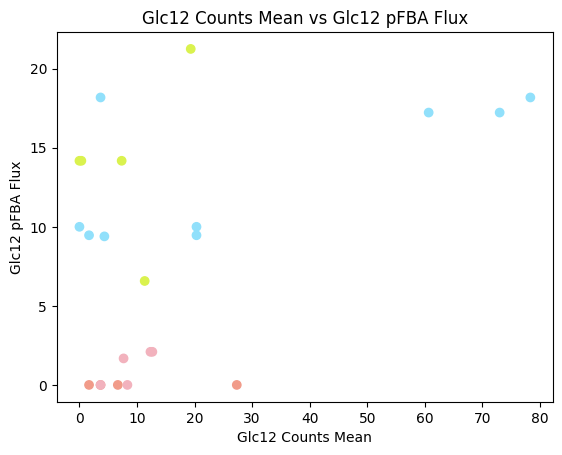

In [57]:
# Scatterplot of Glc12 Count Mean vs Glc12 pFBA
plt.scatter(subset_df["Glc12 Counts Mean"], abs(subset_df["Glc12 pFBA"]), c=subset_df["Function"].map(lambda name: name_to_color[name]))
plt.xlabel("Glc12 Counts Mean")
plt.ylabel("Glc12 pFBA Flux")
plt.title("Glc12 Counts Mean vs Glc12 pFBA Flux")
plt.show()

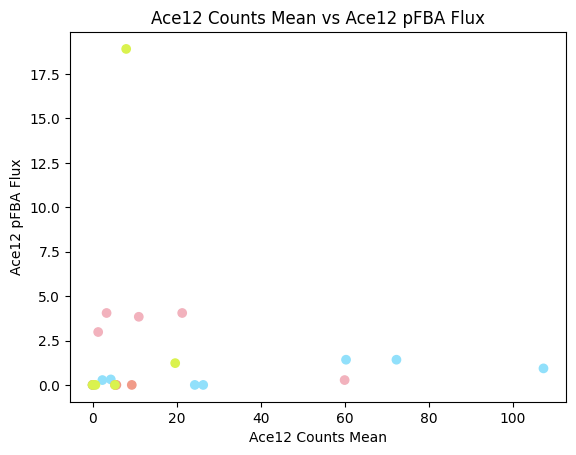

In [58]:
# Scatter plot of Ace12 Count Mean vs Ace12 pFBA
plt.scatter(subset_df["Ace12 Counts Mean"], abs(subset_df["Ace12 pFBA"]), c=subset_df["Function"].map(lambda name: name_to_color[name]))
plt.xlabel("Ace12 Counts Mean")
plt.ylabel("Ace12 pFBA Flux")
plt.title("Ace12 Counts Mean vs Ace12 pFBA Flux")
plt.show()